In [2]:
import cv2
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ultralytics
from ultralytics import YOLO
ultralytics.checks()

Ultralytics YOLOv8.2.2  Python-3.8.3 torch-2.2.2+cpu CPU (AMD Ryzen 5 PRO 5650U with Radeon Graphics)
Setup complete  (12 CPUs, 15.3 GB RAM, 237.4/476.2 GB disk)


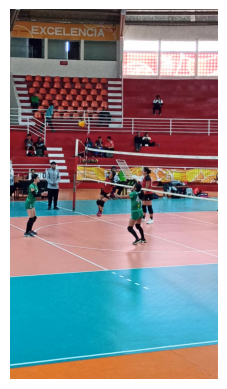

In [3]:
#path0='/content/46_051..jpg'
#"C:\MI-CARRERA\Semestre7\SIS330\PROYECTO\fitro\buenos\desplazamiento2\18-2-Desplazamineto\VID_20240602_104416_000061.jpg"
path0= 'C:\\MI-CARRERA\\Semestre7\\SIS330\\PROYECTO\\fitro\\buenos\\desplazamiento2\\18-2-Desplazamineto\\VID_20240602_104416_000061.jpg'
img=plt.imread(path0)
plt.imshow(img)#, cv2.COLOR_BGR2RGB)
plt.axis('off')
plt.show()

In [5]:
#path0= 'C:\\MI-CARRERA\\Semestre7\\SIS330\\PROYECTO\\prueba\\buenos\\50\\50_01_inicio..jpg'
#image = cv2.imread(path0)
#target_size = (640, 640)
#resized_image = cv2.resize(image, target_size)
#cv2.imshow('Resized Image', resized_image)
#cv2.waitKey(0)
#cv2.destroyAllWindows()


In [4]:
path0= 'C:\\MI-CARRERA\\Semestre7\\SIS330\\PROYECTO\\fitro\\buenos\\desplazamiento2\\18-2-Desplazamineto\\VID_20240602_104416_000061.jpg'
model = YOLO('C:\MI-CARRERA\Semestre7\SIS330\PROYECTO\SIS330\yolov8x-pose.pt')  # load an official model
# Predict with the model
results = model.track(path0,show =False, imgsz=[640, 640] )


image 1/1 C:\MI-CARRERA\Semestre7\SIS330\PROYECTO\fitro\buenos\desplazamiento2\18-2-Desplazamineto\VID_20240602_104416_000061.jpg: 640x384 5 persons, 728.7ms
Speed: 5.8ms preprocess, 728.7ms inference, 1576.0ms postprocess per image at shape (1, 3, 640, 384)


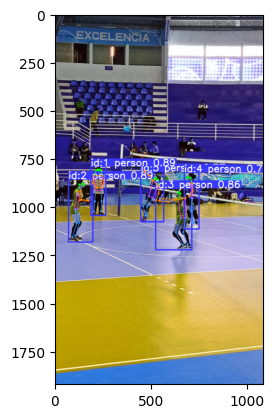

In [5]:
annotated_frame = results[0].plot()
plt.imshow(annotated_frame)#, cv2.COLOR_BGR2RGB)
plt.show()

In [6]:
#path0='C:\\MI-CARRERA\\Semestre7\\SIS330\\PROYECTO\\SIS330\\runs\\pose\\track2\\52_01_inicio..jpg'
#img=plt.imread(path0)
#plt.imshow(img)#, cv2.COLOR_BGR2RGB)
#plt.axis('off')
#plt.show()

In [7]:
print(len(results[0].boxes))

5


In [8]:
BOX=pd.DataFrame(columns=range(7))
for i in range(len(results)):
    arri = pd.DataFrame(results[0].boxes.data.cpu()).astype(float)  # Copiar a la CPU antes de convertir a NumPy
    arri['i']=i
    BOX=pd.concat([BOX,arri],axis=0)
BOX.columns=['x','y','x2','y2','id','confidence','class','']
display(BOX)

,x,y,x2,y2,id,confidence,class,
0,186.0,790.0,263.0,1045.0,1.0,0.892773,0.0,0.0
1,70.0,856.0,196.0,1183.0,2.0,0.887467,0.0,0.0
2,522.0,903.0,710.0,1223.0,3.0,0.862272,0.0,0.0
3,671.0,821.0,747.0,1115.0,4.0,0.783190,0.0,0.0
4,445.0,816.0,564.0,1078.0,5.0,0.771859,0.0,0.0


In [9]:
a=len(results[0].boxes)
print(a)
for i in range(a):
  if results[0].boxes.id[i] == 1:
    #for i in range(len(results)):
    points=results[i].keypoints[i].xyn.data.cpu().numpy()
    #print(points)
    ls=[]
    matriz_np = np.array(points)
    matriz_aplanada_np = matriz_np.flatten()
    valor=matriz_aplanada_np.tolist()
    #print(matriz_aplanada_np.tolist())
    ls.append(valor)
    #print(valor)
    print(ls)

5
[[0.21104101836681366, 0.42277878522872925, 0.21484887599945068, 0.42033112049102783, 0.20638598501682281, 0.4204246699810028, 0.21976128220558167, 0.422050416469574, 0.19826936721801758, 0.42216017842292786, 0.22761361300945282, 0.4371921420097351, 0.1868331879377365, 0.4374842047691345, 0.23579232394695282, 0.45672550797462463, 0.18155784904956818, 0.45747053623199463, 0.2195197343826294, 0.4685157835483551, 0.20388507843017578, 0.46979856491088867, 0.2229369878768921, 0.47703906893730164, 0.19530588388442993, 0.4773394465446472, 0.22411157190799713, 0.5060992240905762, 0.19095353782176971, 0.506388783454895, 0.22102293372154236, 0.5337402820587158, 0.18790139257907867, 0.5339425206184387]]


In [10]:
df = pd.DataFrame(ls)
print(df)
df.to_csv("buen"+".txt")

         0         1         2         3         4         5         6   \
0  0.211041  0.422779  0.214849  0.420331  0.206386  0.420425  0.219761   

        7         8        9   ...        24        25        26        27  \
0  0.42205  0.198269  0.42216  ...  0.195306  0.477339  0.224112  0.506099   

         28        29        30       31        32        33  
0  0.190954  0.506389  0.221023  0.53374  0.187901  0.533943  

[1 rows x 34 columns]


In [66]:
import os
import cv2
from ultralytics import YOLO

# Directorio principal que contiene subcarpetas con imágenes
#C:\MI-CARRERA\Semestre7\SIS330\PROYECTO\fitro\buenos
directorio_principal = "C:\\MI-CARRERA\\Semestre7\\SIS330\\PROYECTO\\fitro\\malos\\golpeo"

# Directorio donde se guardarán los resultados
directorio_resultados = "C:\\MI-CARRERA\\Semestre7\\SIS330\\PROYECTO\\fitro\\malos\\golpeo"
resultados_carpeta_actual = []
# Load the YOLOv8 model
for carpeta in os.listdir(directorio_principal):
    print("entro",carpeta)
    carpeta_actual = os.path.join(directorio_principal, carpeta)
    if os.path.isdir(carpeta_actual):
        # Crear una nueva instancia del modelo YOLO para cada carpeta
        model = YOLO('C:\EV\PROYECTO\yolov8x-pose.pt')
        
        # Carpeta donde se guardarán los resultados para esta carpeta
        carpeta_resultados = os.path.join(directorio_resultados, carpeta+"resultados")
        os.makedirs(carpeta_resultados, exist_ok=True)
        
        # Procesar cada imagen en la carpeta actual
        for archivo in os.listdir(carpeta_actual):
            ruta_archivo = os.path.join(carpeta_actual, archivo)
            # Leer el fotograma del archivo
            frame = cv2.imread(ruta_archivo)

            # Run YOLOv8 tracking on the frame, persisting tracks between frames
            results = model.track(frame, persist=True)
            # Extrae keypoints de este ID específico
            a = len(results[0].boxes)
            print(a)
            #resultados_carpeta_actual = []
            for i in range(a):
                if results[0].boxes.id[i] == 9:
                    keypoints_de_interes = results[0].keypoints[i].xyn.data.cpu().numpy()
                    matriz_np = np.array(keypoints_de_interes)
                    matriz_aplanada_np = matriz_np.flatten()
                    valor = matriz_aplanada_np.tolist()
                    resultados_carpeta_actual.append(valor)
            # Visualize the results on the frame
            annotated_frame = results[0].plot()
            # Guardar el resultado en la carpeta 'malos_resultados' específica para esta carpeta
            cv2.imwrite(os.path.join(carpeta_resultados, archivo), annotated_frame)

# Informar que la operación ha finalizado
print("Proceso completado.")


entro 68-i-golpeo-i9

0: 384x640 12 persons, 637.4ms
Speed: 2.0ms preprocess, 637.4ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)
12

0: 384x640 12 persons, 549.1ms
Speed: 2.0ms preprocess, 549.1ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
12

0: 384x640 12 persons, 571.5ms
Speed: 2.0ms preprocess, 571.5ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
12

0: 384x640 11 persons, 607.8ms
Speed: 2.0ms preprocess, 607.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
11

0: 384x640 11 persons, 559.0ms
Speed: 2.0ms preprocess, 559.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
11

0: 384x640 11 persons, 560.3ms
Speed: 2.0ms preprocess, 560.3ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
11

0: 384x640 11 persons, 602.7ms
Speed: 1.3ms preprocess, 602.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)
11

0: 384x640 11 persons, 572.4ms
Speed: 2.0ms pre

In [15]:
#path0= 'C:\\MI-CARRERA\\Semestre7\\SIS330\\PROYECTO\\prueba\\buenos\\94resultados\\94_01_inicio..jpg'
#img=plt.imread(path0)
#plt.imshow(img)#, cv2.COLOR_BGR2RGB)
#plt.axis('off')
#plt.show()

In [67]:
b=resultados_carpeta_actual
print(len(b))
df = pd.DataFrame(resultados_carpeta_actual)
print(df)

24
          0         1         2         3    4    5         6         7   \
0   0.000000  0.000000  0.755179  0.452217  0.0  0.0  0.759303  0.463297   
1   0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.746521  0.444703   
2   0.739634  0.426239  0.742278  0.423642  0.0  0.0  0.750541  0.433554   
3   0.738148  0.380618  0.741086  0.375717  0.0  0.0  0.748968  0.379230   
4   0.747629  0.384381  0.000000  0.000000  0.0  0.0  0.752947  0.397572   
5   0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.749756  0.402829   
6   0.735192  0.366557  0.738587  0.364458  0.0  0.0  0.745636  0.373335   
7   0.733879  0.368716  0.737261  0.366877  0.0  0.0  0.742621  0.374118   
8   0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.000000  0.000000   
9   0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.000000  0.000000   
10  0.732064  0.374792  0.735682  0.373540  0.0  0.0  0.741222  0.378599   
11  0.000000  0.000000  0.000000  0.000000  0.0  0.0  0.000000  0.000000   
12  0.721

In [68]:
df.to_csv("malosgolpeo9"+".txt")

In [18]:
# Visualize the results on the frame
#annotated_frame = results[0].plot()
# Display the annotated frame
#cv2.imshow("detect",annotated_frame)

In [19]:
import os
import cv2
from ultralytics import YOLO

# Load the YOLOv8 model
model = YOLO('yolov8x-pose.pt')
##C:\MI-CARRERA\Semestre 7\SIS330\PROYECTO\Nueva carpeta\imagenes\malos
#C:\MI-CARRERA\Semestre 7\SIS330\PROYECTO\Nueva carpeta\imagenes\buenos
directorio_principal = "C:\\MI-CARRERA\\Semestre7\\SIS330\\imagenes\\malos\\17-malo-4"
guardar= "C:\\MI-CARRERA\\Semestre7\\SIS330\\imagenes\\malos"
resultados_carpeta_actual2=[]
for archivo in os.listdir(directorio_principal):
    
    ruta_archivo = os.path.join(directorio_principal, archivo)
      
    # Leer el fotograma del archivo
    frame = cv2.imread(ruta_archivo)

    # Run YOLOv8 tracking on the frame, persisting tracks between frames
    results = model.track(frame, persist=True)
    # Extrae keypoints de este ID específico
    a= len(results[0].boxes)
    #print(results[0].boxes)
    for i in range(a):
      #print(i)
      if results[0].boxes.id[i] == 4:
        keypoints_de_interes = results[0].keypoints[i].xyn.data.cpu().numpy()
        matriz_np = np.array(keypoints_de_interes)
        matriz_aplanada_np = matriz_np.flatten()
        valor=matriz_aplanada_np.tolist()
        resultados_carpeta_actual2.append(valor)
    # Visualize the results on the frame
    annotated_frame = results[0].plot()
    # Guardar el resultado en la carpeta 'buenos_resultados'
    carpeta_resultados = os.path.join(guardar, "17-resultados")
    os.makedirs(carpeta_resultados, exist_ok=True)
    cv2.imwrite(os.path.join(carpeta_resultados, archivo), annotated_frame)

# Informar que la operación ha finalizado
print("Proceso completado.")
#print(resultados_carpeta_actual)

Proceso completado.


In [20]:
df = pd.DataFrame(resultados_carpeta_actual2)
print(df)
df.to_csv("malo4-real"+".txt")

Empty DataFrame
Columns: []
Index: []
